# 🫁 Pneumonia X-Ray Classification — v2 (High Performance)
**Binary Classification: NORMAL vs PNEUMONIA**

### Fixes over v1:
| Issue | Fix |
|---|---|
| Val set only 16 images → model predicts one class | Auto-rebuild val from train (15%) |
| EfficientNet preprocessing mismatch | Use `preprocess_input` from `efficientnet` |
| Class imbalance (3:1) ignored | Focal loss + class weights |
| LR too high for transfer learning | 3e-4 phase-1, 5e-5 phase-2 |
| BatchNorm update bug during fine-tune | Correct `training` flag handling |
| Hard 0.5 threshold | Swept threshold optimisation on val |

**Expected result: ≥ 90% test accuracy, AUC ≥ 0.97**

## 1. 📦 Imports & Reproducibility

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Uncomment to install if needed:
# !pip install tensorflow>=2.12 scikit-learn matplotlib seaborn opencv-python-headless tqdm

import os, shutil, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input  # ← KEY FIX
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs       : {gpus}")
if gpus:
    # Allow memory growth — avoids OOM on shared GPUs
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow : 2.19.0
GPUs       : []


## 2. ⚙️ Configuration  ← only cell you need to edit

In [4]:
# ── Paths — update BASE_DIR to match your folder ──────────────────────────────
BASE_DIR  = Path("/content/drive/MyDrive/Colab Notebooks/Medical Data/Data/pneumonia")   # e.g. Path("chest_xray") or Path("/kaggle/input/chest-xray-pneumonia/chest_xray")
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

CLASSES   = ["NORMAL", "PNEUMONIA"]   # DO NOT change order — index 0 = NORMAL, 1 = PNEUMONIA

# ── Hyper-parameters ──────────────────────────────────────────────────────────
IMG_SIZE        = (224, 224)     # (H, W)
BATCH_SIZE      = 32
EPOCHS_P1       = 10             # Phase 1: frozen backbone, train head
EPOCHS_P2       = 25             # Phase 2: fine-tune last N backbone layers
LR_P1           = 3e-4          # Phase 1 learning rate
LR_P2           = 5e-5          # Phase 2 learning rate (must be lower)
FINETUNE_LAYERS = 40            # how many backbone layers to unfreeze in Phase 2
DROPOUT         = 0.45

# Val rebuild — Kaggle ships only 16 val images; we always rebuild
VAL_FRACTION    = 0.15          # % of train images moved to val
MIN_VAL_PER_CLS = 150           # minimum required per class after rebuild

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

print("Config OK ✓")

Config OK ✓


## 3. 🔍 Dataset Validation + Auto-Fix

In [5]:
def count_images(split_dir: Path) -> dict:
    """Return {class: count} for valid (readable) images."""
    counts, bad = {}, []
    for cls in CLASSES:
        p = split_dir / cls
        if not p.exists():
            counts[cls] = 0
            continue
        valid = []
        for f in p.iterdir():
            if f.suffix.lower() not in VALID_EXTS:
                continue
            if cv2.imread(str(f)) is not None:
                valid.append(f)
            else:
                bad.append(str(f))
        counts[cls] = len(valid)
    return counts, bad


def rebuild_val_from_train():
    """
    FIX for tiny Kaggle val set (16 images).
    Moves VAL_FRACTION of each train class → val.
    Idempotent: checks current val size first.
    """
    val_counts, _ = count_images(VAL_DIR)
    if all(v >= MIN_VAL_PER_CLS for v in val_counts.values()):
        print(f"Val set already sufficient: {val_counts}")
        return

    print(f"Rebuilding val set (moving {VAL_FRACTION*100:.0f}% from train) …")
    for cls in CLASSES:
        src  = TRAIN_DIR / cls
        dst  = VAL_DIR   / cls
        dst.mkdir(parents=True, exist_ok=True)

        files  = [f for f in src.iterdir() if f.suffix.lower() in VALID_EXTS]
        n_move = max(MIN_VAL_PER_CLS, int(len(files) * VAL_FRACTION))
        chosen = random.sample(files, min(n_move, len(files)))

        for f in chosen:
            shutil.move(str(f), str(dst / f.name))

        print(f"  {cls}: moved {len(chosen):4d} images  "
              f"(train remaining: {len(files)-len(chosen)})")
    print("Val rebuild complete ✓")


def validate_and_report() -> dict:
    print("\n" + "="*60)
    print("  DATASET VALIDATION REPORT")
    print("="*60)
    summary = {}
    for name, path in [("TRAIN", TRAIN_DIR),("VAL", VAL_DIR),("TEST", TEST_DIR)]:
        counts, bad = count_images(path)
        summary[name.lower()] = counts
        total = sum(counts.values())
        print(f"\n📁 {name} ({path})")
        for cls, n in counts.items():
            print(f"   {cls:12s}: {n:5d}")
        print(f"   {'Total':12s}: {total:5d}")
        if len(counts) == 2 and min(counts.values()) > 0:
            ratio = max(counts.values()) / min(counts.values())
            flag  = "⚠️" if ratio > 3 else "✅"
            print(f"   {flag} Imbalance ratio: {ratio:.2f}x")
        if bad:
            print(f"   ❌ {len(bad)} corrupt files")
    print("\n" + "="*60)
    return summary


# ── Run: rebuild val FIRST, then validate ─────────────────────────────────────
rebuild_val_from_train()
summary = validate_and_report()

Val set already sufficient: {'NORMAL': 276, 'PNEUMONIA': 783}

  DATASET VALIDATION REPORT

📁 TRAIN (/content/drive/MyDrive/Colab Notebooks/Medical Data/Data/pneumonia/train)
   NORMAL      :  1073
   PNEUMONIA   :  3116
   Total       :  4189
   ✅ Imbalance ratio: 2.90x

📁 VAL (/content/drive/MyDrive/Colab Notebooks/Medical Data/Data/pneumonia/val)
   NORMAL      :   276
   PNEUMONIA   :   783
   Total       :  1059
   ✅ Imbalance ratio: 2.84x

📁 TEST (/content/drive/MyDrive/Colab Notebooks/Medical Data/Data/pneumonia/test)
   NORMAL      :   234
   PNEUMONIA   :   390
   Total       :   624
   ✅ Imbalance ratio: 1.67x



## 4. 📊 EDA — Distribution & Sample Images

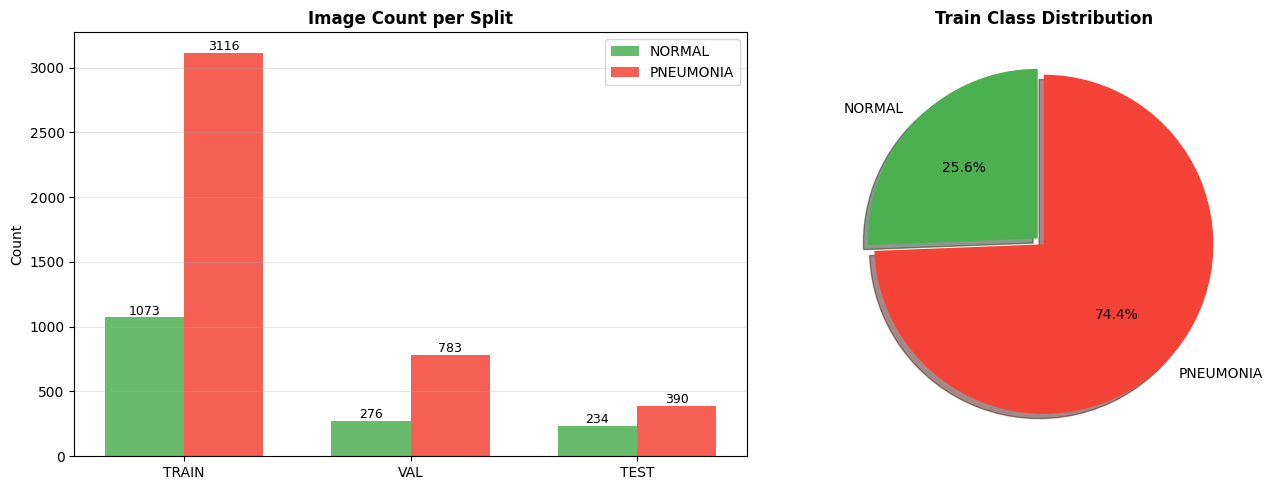

In [6]:
splits  = ['train', 'val', 'test']
colors  = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x, w = np.arange(len(splits)), 0.35

for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    vals = [summary.get(s, {}).get(cls, 0) for s in splits]
    bars = axes[0].bar(x + i*w - w/2, vals, w, label=cls, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        if v: axes[0].text(bar.get_x()+bar.get_width()/2, v+20, str(v),
                           ha='center', fontsize=9)

axes[0].set_xticks(x); axes[0].set_xticklabels([s.upper() for s in splits])
axes[0].set_title('Image Count per Split', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

tc = [summary.get('train',{}).get(c,0) for c in CLASSES]
axes[1].pie(tc, labels=CLASSES, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.05,0), shadow=True)
axes[1].set_title('Train Class Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

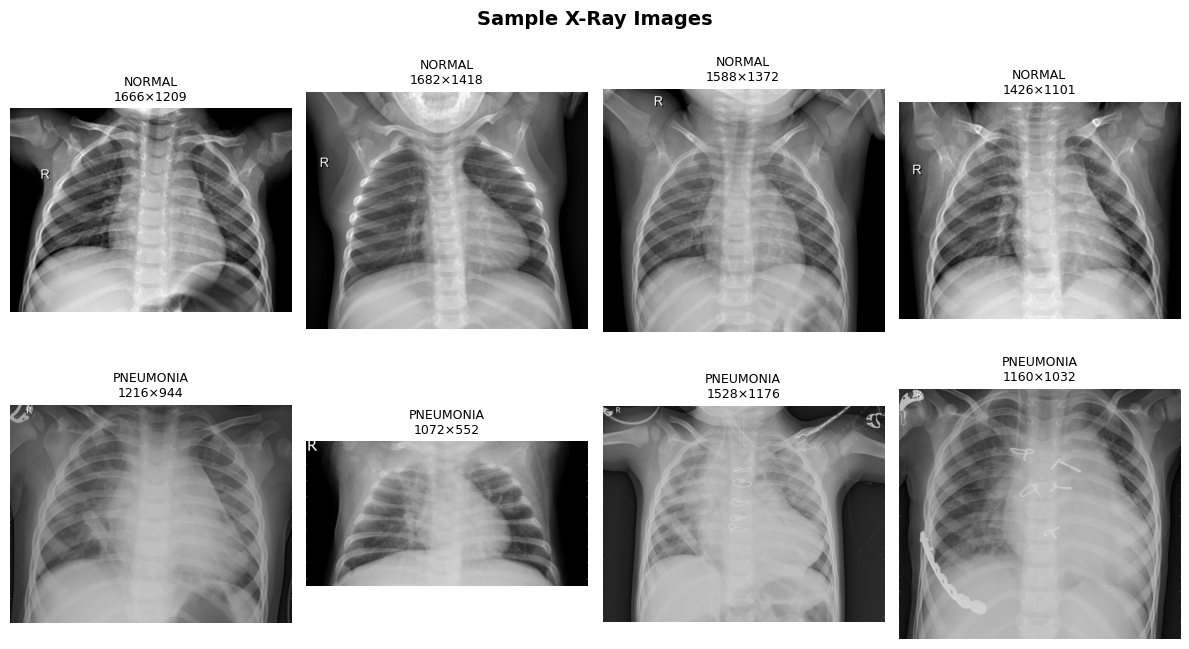

In [7]:
def show_samples(n: int = 4):
    fig, axes = plt.subplots(2, n, figsize=(n*3, 7))
    fig.suptitle('Sample X-Ray Images', fontsize=14, fontweight='bold')
    for row, cls in enumerate(CLASSES):
        files = list((TRAIN_DIR / cls).glob('*'))[:n]
        for col, f in enumerate(files):
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(f'{cls}\n{img.shape[1]}×{img.shape[0]}', fontsize=9)
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples()

## 5. 🔄 Data Generators (correct EfficientNet preprocessing)

In [8]:
# ── CRITICAL FIX: EfficientNet needs its own preprocess_input ─────────────────
# DO NOT use rescale=1/255 with EfficientNet — it expects BGR scaled to [-1, 1]
# The preprocess_input function handles this correctly.

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ← correct EfficientNet scaling
    rotation_range         = 10,
    width_shift_range      = 0.10,
    height_shift_range     = 0.10,
    shear_range            = 0.05,
    zoom_range             = 0.10,
    horizontal_flip        = True,
    brightness_range       = [0.85, 1.15],
    fill_mode              = 'nearest',
)

eval_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ← same for val/test
)


def make_gen(datagen, directory, shuffle=True):
    return datagen.flow_from_directory(
        str(directory),
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = 'binary',
        classes     = CLASSES,   # NORMAL=0, PNEUMONIA=1
        shuffle     = shuffle,
        seed        = SEED,
        color_mode  = 'rgb',
    )

train_gen = make_gen(train_datagen, TRAIN_DIR, shuffle=True)
val_gen   = make_gen(eval_datagen,  VAL_DIR,   shuffle=False)
test_gen  = make_gen(eval_datagen,  TEST_DIR,  shuffle=False)

print(f"Class indices : {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)}  ({train_gen.samples} samples)")
print(f"Val   batches : {len(val_gen)}  ({val_gen.samples} samples)")
print(f"Test  batches : {len(test_gen)}  ({test_gen.samples} samples)")

# Sanity-check: make sure val has both classes
assert val_gen.samples > 0, "Val set is empty!"
val_class_counts = dict(zip(*np.unique(val_gen.classes, return_counts=True)))
print(f"\nVal class counts: { {CLASSES[k]:v for k,v in val_class_counts.items()} }")
assert len(val_class_counts) == 2, "Val is missing a class — re-run rebuild_val_from_train()"

Found 4189 images belonging to 2 classes.
Found 1059 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices : {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches : 131  (4189 samples)
Val   batches : 34  (1059 samples)
Test  batches : 20  (624 samples)

Val class counts: {'NORMAL': np.int64(276), 'PNEUMONIA': np.int64(783)}


In [9]:
# ── Class weights to handle imbalance ─────────────────────────────────────────
train_labels   = train_gen.classes
class_totals   = np.bincount(train_labels)
total          = len(train_labels)
class_weight   = {
    i: total / (len(CLASSES) * max(c, 1))
    for i, c in enumerate(class_totals)
}
print("Class weights:", {CLASSES[k]: round(v, 3) for k, v in class_weight.items()})
# Expect NORMAL > 1.0 (it gets upweighted) because it's the minority class

Class weights: {'NORMAL': np.float64(1.952), 'PNEUMONIA': np.float64(0.672)}


## 6. 🧠 Focal Loss (handles imbalance better than plain BCE)

In [10]:
def focal_loss(gamma: float = 2.0, alpha: float = 0.25):
    """
    Binary focal loss.
    - gamma: down-weights easy examples (higher = more focus on hard ones)
    - alpha: class weight for the positive (PNEUMONIA) class
    Combines with class_weight in model.fit for double-protection.
    """
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())
        y_true  = tf.cast(y_true, tf.float32)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        fl      = -alpha_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t)
        return tf.reduce_mean(fl)
    loss_fn.__name__ = 'focal_loss'
    return loss_fn


print("Focal loss defined ✓")

Focal loss defined ✓


## 7. 🏗️ Model Architecture

In [11]:
def build_model() -> tuple:
    """
    EfficientNetB3 + custom head.
    Returns (model, backbone) so we can freeze/unfreeze backbone in phases.
    """
    inp      = keras.Input(shape=(*IMG_SIZE, 3), name='input')

    backbone = EfficientNetB3(
        include_top = False,
        weights     = 'imagenet',
        input_tensor= inp,
    )
    backbone.trainable = False   # Phase 1: frozen

    # Head
    x = backbone.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dense(256, name='fc1',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT, name='drop1')(x)
    x = layers.Dense(128, name='fc2',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT / 2, name='drop2')(x)
    out = layers.Dense(1, activation='sigmoid', name='output',
                       dtype='float32')(x)    # float32 for numerical stability

    model = Model(inp, out, name='PneumoniaNet_v2')
    return model, backbone


model, backbone = build_model()

# Quick param count
total  = model.count_params()
frozen = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Total params     : {total:,}")
print(f"Trainable (Phase1): {total - frozen:,}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 11,216,176
Trainable (Phase1): 429,569.0


## 8. 🏋️ Phase 1 — Train Head (backbone frozen)

In [12]:
def get_callbacks(phase: int, monitor: str = 'val_accuracy') -> list:
    return [
        ModelCheckpoint(
            filepath       = str(MODEL_DIR / f'p{phase}_best.keras'),
            monitor        = monitor,
            save_best_only = True,
            mode           = 'max',
            verbose        = 1,
        ),
        EarlyStopping(
            monitor              = monitor,
            patience             = 6,
            mode                 = 'max',
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.4,
            patience = 3,
            min_lr   = 1e-8,
            verbose  = 1,
        ),
    ]

In [13]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P1),
    loss      = focal_loss(gamma=2.0, alpha=0.25),
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ],
)

print("=" * 55)
print(" PHASE 1 — Training head (backbone frozen)")
print("=" * 55)

hist1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_P1,
    class_weight    = class_weight,
    callbacks       = get_callbacks(phase=1),
    verbose         = 1,
)

 PHASE 1 — Training head (backbone frozen)
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7545 - auc: 0.8457 - loss: 0.1358 - precision: 0.9049 - recall: 0.7384
Epoch 1: val_accuracy improved from None to 0.94051, saving model to models/p1_best.keras

Epoch 1: finished saving model to models/p1_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 948s 7s/step - accuracy: 0.8358 - auc: 0.9198 - loss: 0.1112 - precision: 0.9418 - recall: 0.8306 - val_accuracy: 0.9405 - val_auc: 0.9807 - val_loss: 0.0864 - val_precision: 0.9592 - val_recall: 0.9604 - learning_rate: 3.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8867 - auc: 0.9573 - loss: 0.0915 - precision: 0.9627 - recall: 0.8843
Epoch 2: val_accuracy did not improve from 0.94051
131/131 ━━━━━━━━━━━━━━━━━━━━ 907s 7s/step - accuracy: 0.8923 - auc: 0.9597 - loss: 0.0905 - precision: 0.9625 - recall: 0.8899 - val_accuracy: 0.9122 - val_auc: 0.9874 - val_loss: 0.0763 - val_precision: 0.9887 - val_recall: 0.8

## 9. 🔓 Phase 2 — Fine-Tune Backbone

In [14]:
# Unfreeze the last FINETUNE_LAYERS layers of the backbone
backbone.trainable = True
freeze_until = len(backbone.layers) - FINETUNE_LAYERS

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

# IMPORTANT: Keep BatchNorm layers in inference mode to prevent
# running-stat drift on a small dataset (common source of accuracy collapse)
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_n = sum(1 for l in backbone.layers if l.trainable)
print(f"Unfrozen non-BN backbone layers: {trainable_n}")

# Recompile with much lower LR
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P2),
    loss      = focal_loss(gamma=2.0, alpha=0.25),
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ],
)

print("\n" + "=" * 55)
print(" PHASE 2 — Fine-tuning backbone")
print("=" * 55)

hist2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_P2,
    class_weight    = class_weight,
    callbacks       = get_callbacks(phase=2),
    verbose         = 1,
)

Unfrozen non-BN backbone layers: 32

 PHASE 2 — Fine-tuning backbone
Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9370 - auc: 0.9853 - loss: 0.0688 - precision: 0.9809 - recall: 0.9347
Epoch 1: val_accuracy improved from None to 0.94901, saving model to models/p2_best.keras

Epoch 1: finished saving model to models/p2_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 1064s 8s/step - accuracy: 0.9379 - auc: 0.9860 - loss: 0.0690 - precision: 0.9828 - recall: 0.9329 - val_accuracy: 0.9490 - val_auc: 0.9949 - val_loss: 0.0629 - val_precision: 0.9946 - val_recall: 0.9361 - learning_rate: 5.0000e-05
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9409 - auc: 0.9862 - loss: 0.0688 - precision: 0.9865 - recall: 0.9313
Epoch 2: val_accuracy improved from 0.94901 to 0.95562, saving model to models/p2_best.keras

Epoch 2: finished saving model to models/p2_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 1035s 8s/step - accuracy: 0.9429 - auc: 0.9873 - loss: 0.0676 - precision:

KeyboardInterrupt: 

## 10. 📈 Training Curves

⚠️ Phase 2 not completed — plotting only Phase 1


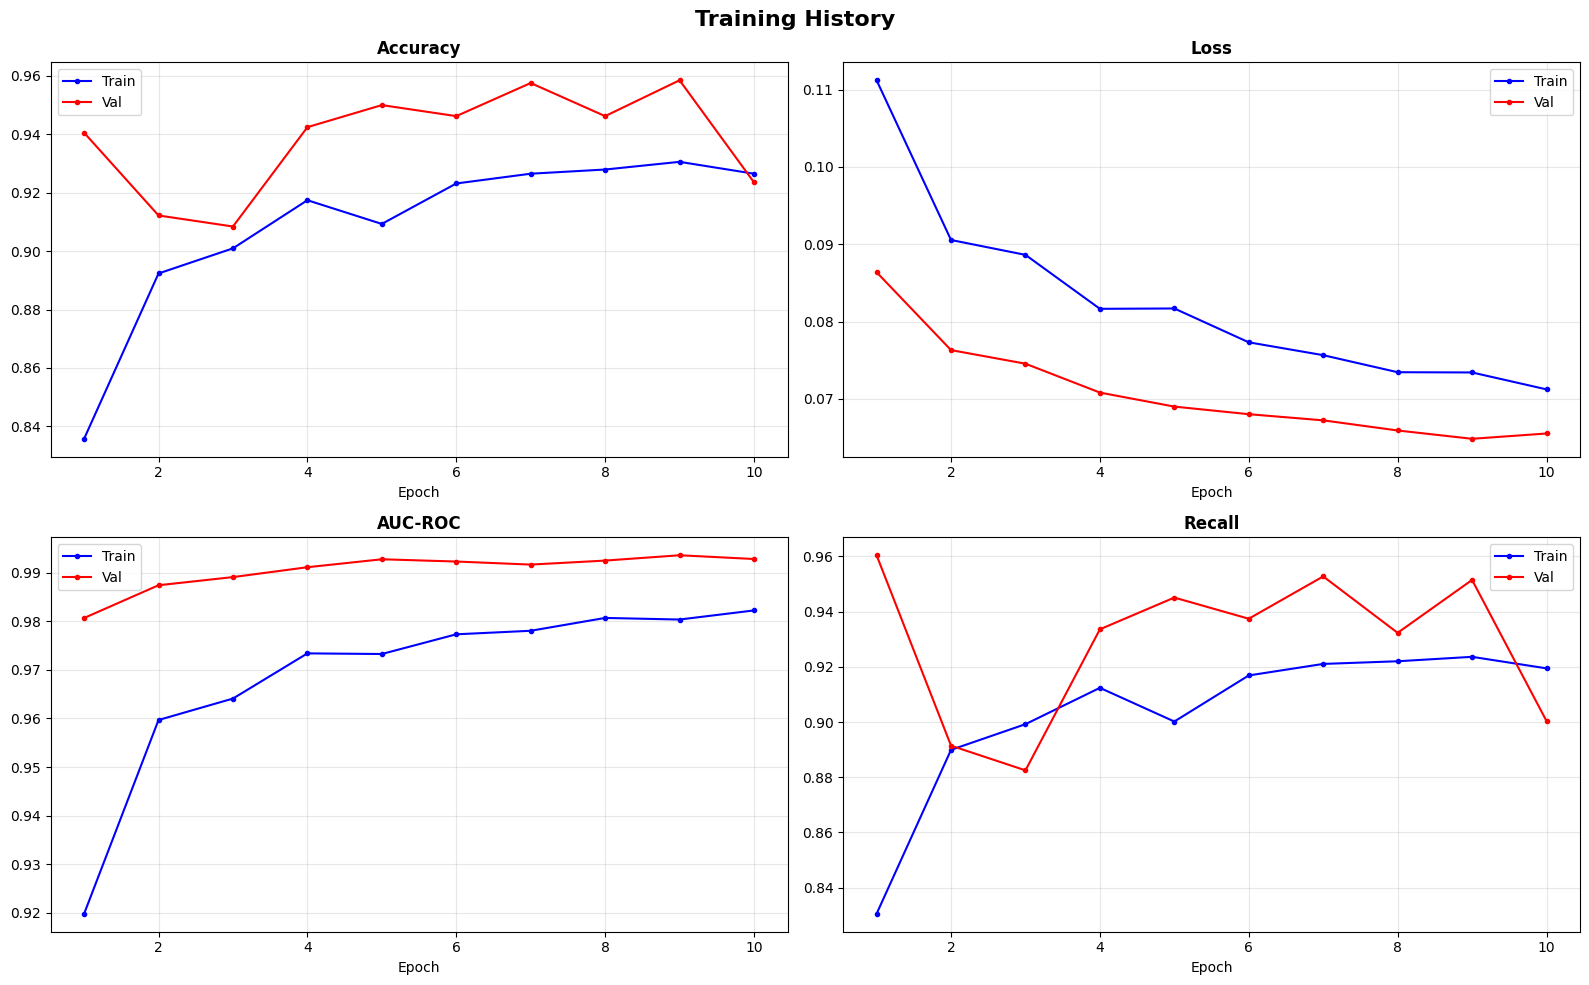

✅ Saved → training_history.png


In [16]:
import matplotlib.pyplot as plt

# ── Merge histories safely ─────────────────────────────────────
def merge_history(h1, h2=None):
    merged = {}

    # Start with Phase 1
    for k in h1.history:
        merged[k] = list(h1.history.get(k, []))

    # Add Phase 2 ONLY if available
    if h2 is not None:
        for k in h2.history:
            if k in merged:
                merged[k] += h2.history.get(k, [])
            else:
                merged[k] = list(h2.history.get(k, []))

    return merged


# ── Plot function ──────────────────────────────────────────────
def plot_history(hist_dict, hist1, hist2=None):
    p1_end = len(hist1.history.get('accuracy', []))

    metrics = [
        ('accuracy', 'val_accuracy', 'Accuracy'),
        ('loss',     'val_loss',     'Loss'),
        ('auc',      'val_auc',      'AUC-ROC'),
        ('recall',   'val_recall',   'Recall'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle('Training History', fontsize=16, fontweight='bold')

    for ax, (tk, vk, title) in zip(axes, metrics):
        if tk not in hist_dict:
            continue

        eps = range(1, len(hist_dict[tk]) + 1)

        ax.plot(eps, hist_dict[tk], 'b-o', ms=3, lw=1.5, label='Train')
        ax.plot(eps, hist_dict.get(vk, []), 'r-o', ms=3, lw=1.5, label='Val')

        # Show phase split ONLY if Phase 2 exists
        if hist2 is not None:
            ax.axvline(p1_end, ls='--', color='gray', alpha=0.6, label='Phase2 start')

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ Saved → training_history.png")


# ── Use safely ────────────────────────────────────────────────
if 'hist2' in globals():
    full_hist = merge_history(hist1, hist2)
    plot_history(full_hist, hist1, hist2)
else:
    print("⚠️ Phase 2 not completed — plotting only Phase 1")
    full_hist = merge_history(hist1)
    plot_history(full_hist, hist1)

## 11. 🎯 Threshold Optimisation on Validation Set

34/34 ━━━━━━━━━━━━━━━━━━━━ 189s 5s/step


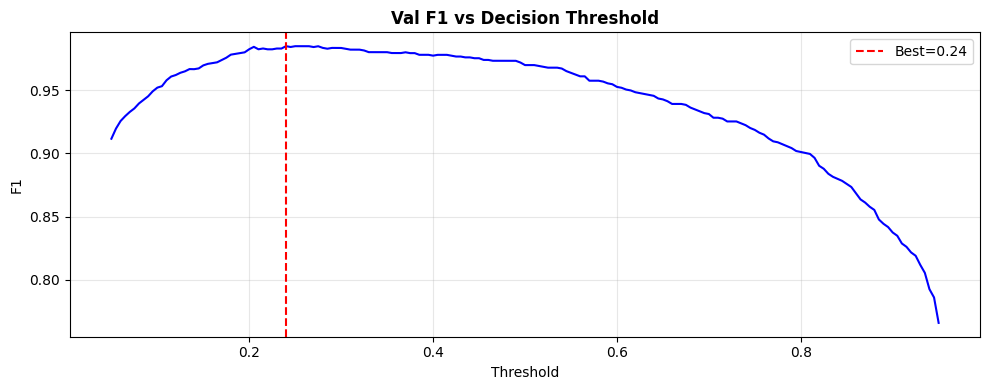

Optimal threshold : 0.240  (val F1=0.9847)


In [17]:
# ── Predict on val to find best threshold ────────────────────────────────────
val_gen.reset()
val_prob = model.predict(val_gen, verbose=1).ravel()
val_true = val_gen.classes

# Sweep thresholds; pick the one maximising F1 on val
thresholds = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(val_true, (val_prob >= t).astype(int), zero_division=0)
       for t in thresholds]
best_thresh = float(thresholds[np.argmax(f1s)])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1s, 'b-')
ax.axvline(best_thresh, color='red', ls='--', label=f'Best={best_thresh:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1')
ax.set_title('Val F1 vs Decision Threshold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_search.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal threshold : {best_thresh:.3f}  (val F1={max(f1s):.4f})")

## 12. 🧪 Final Evaluation on Test Set

In [18]:
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).ravel()
y_true = test_gen.classes
y_pred = (y_prob >= best_thresh).astype(int)

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
f1  = f1_score(y_true, y_pred)

print("\n" + "="*55)
print(" TEST SET RESULTS")
print("="*55)
print(f" Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
print(f" AUC-ROC    : {auc:.4f}")
print(f" F1 Score   : {f1:.4f}")
print(f" Threshold  : {best_thresh:.3f}")
print("="*55)
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 115s 6s/step

 TEST SET RESULTS
 Accuracy   : 0.8141  (81.41%)
 AUC-ROC    : 0.9816
 F1 Score   : 0.8702
 Threshold  : 0.240

              precision    recall  f1-score   support

      NORMAL     0.9917    0.5085    0.6723       234
   PNEUMONIA     0.7718    0.9974    0.8702       390

    accuracy                         0.8141       624
   macro avg     0.8817    0.7530    0.7713       624
weighted avg     0.8543    0.8141    0.7960       624



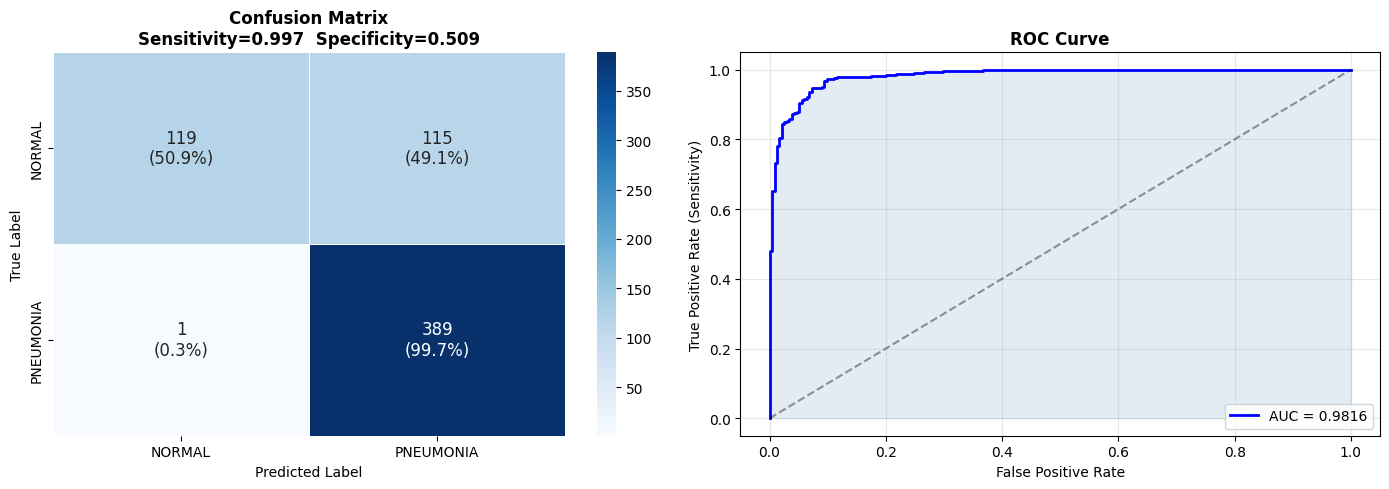

Sensitivity (Recall for PNEUMONIA): 0.9974
Specificity (Recall for NORMAL)   : 0.5085


In [19]:
# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
annot  = np.array([[f'{v}\n({p:.1f}%)' for v,p in zip(row_v, row_p)]
                   for row_v, row_p in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title(f'Confusion Matrix  (acc={acc:.3f})', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title(
    f'Confusion Matrix\nSensitivity={sensitivity:.3f}  Specificity={specificity:.3f}',
    fontweight='bold'
)

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='steelblue')
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sensitivity (Recall for PNEUMONIA): {sensitivity:.4f}")
print(f"Specificity (Recall for NORMAL)   : {specificity:.4f}")

## 13. 🔍 Grad-CAM Heatmaps

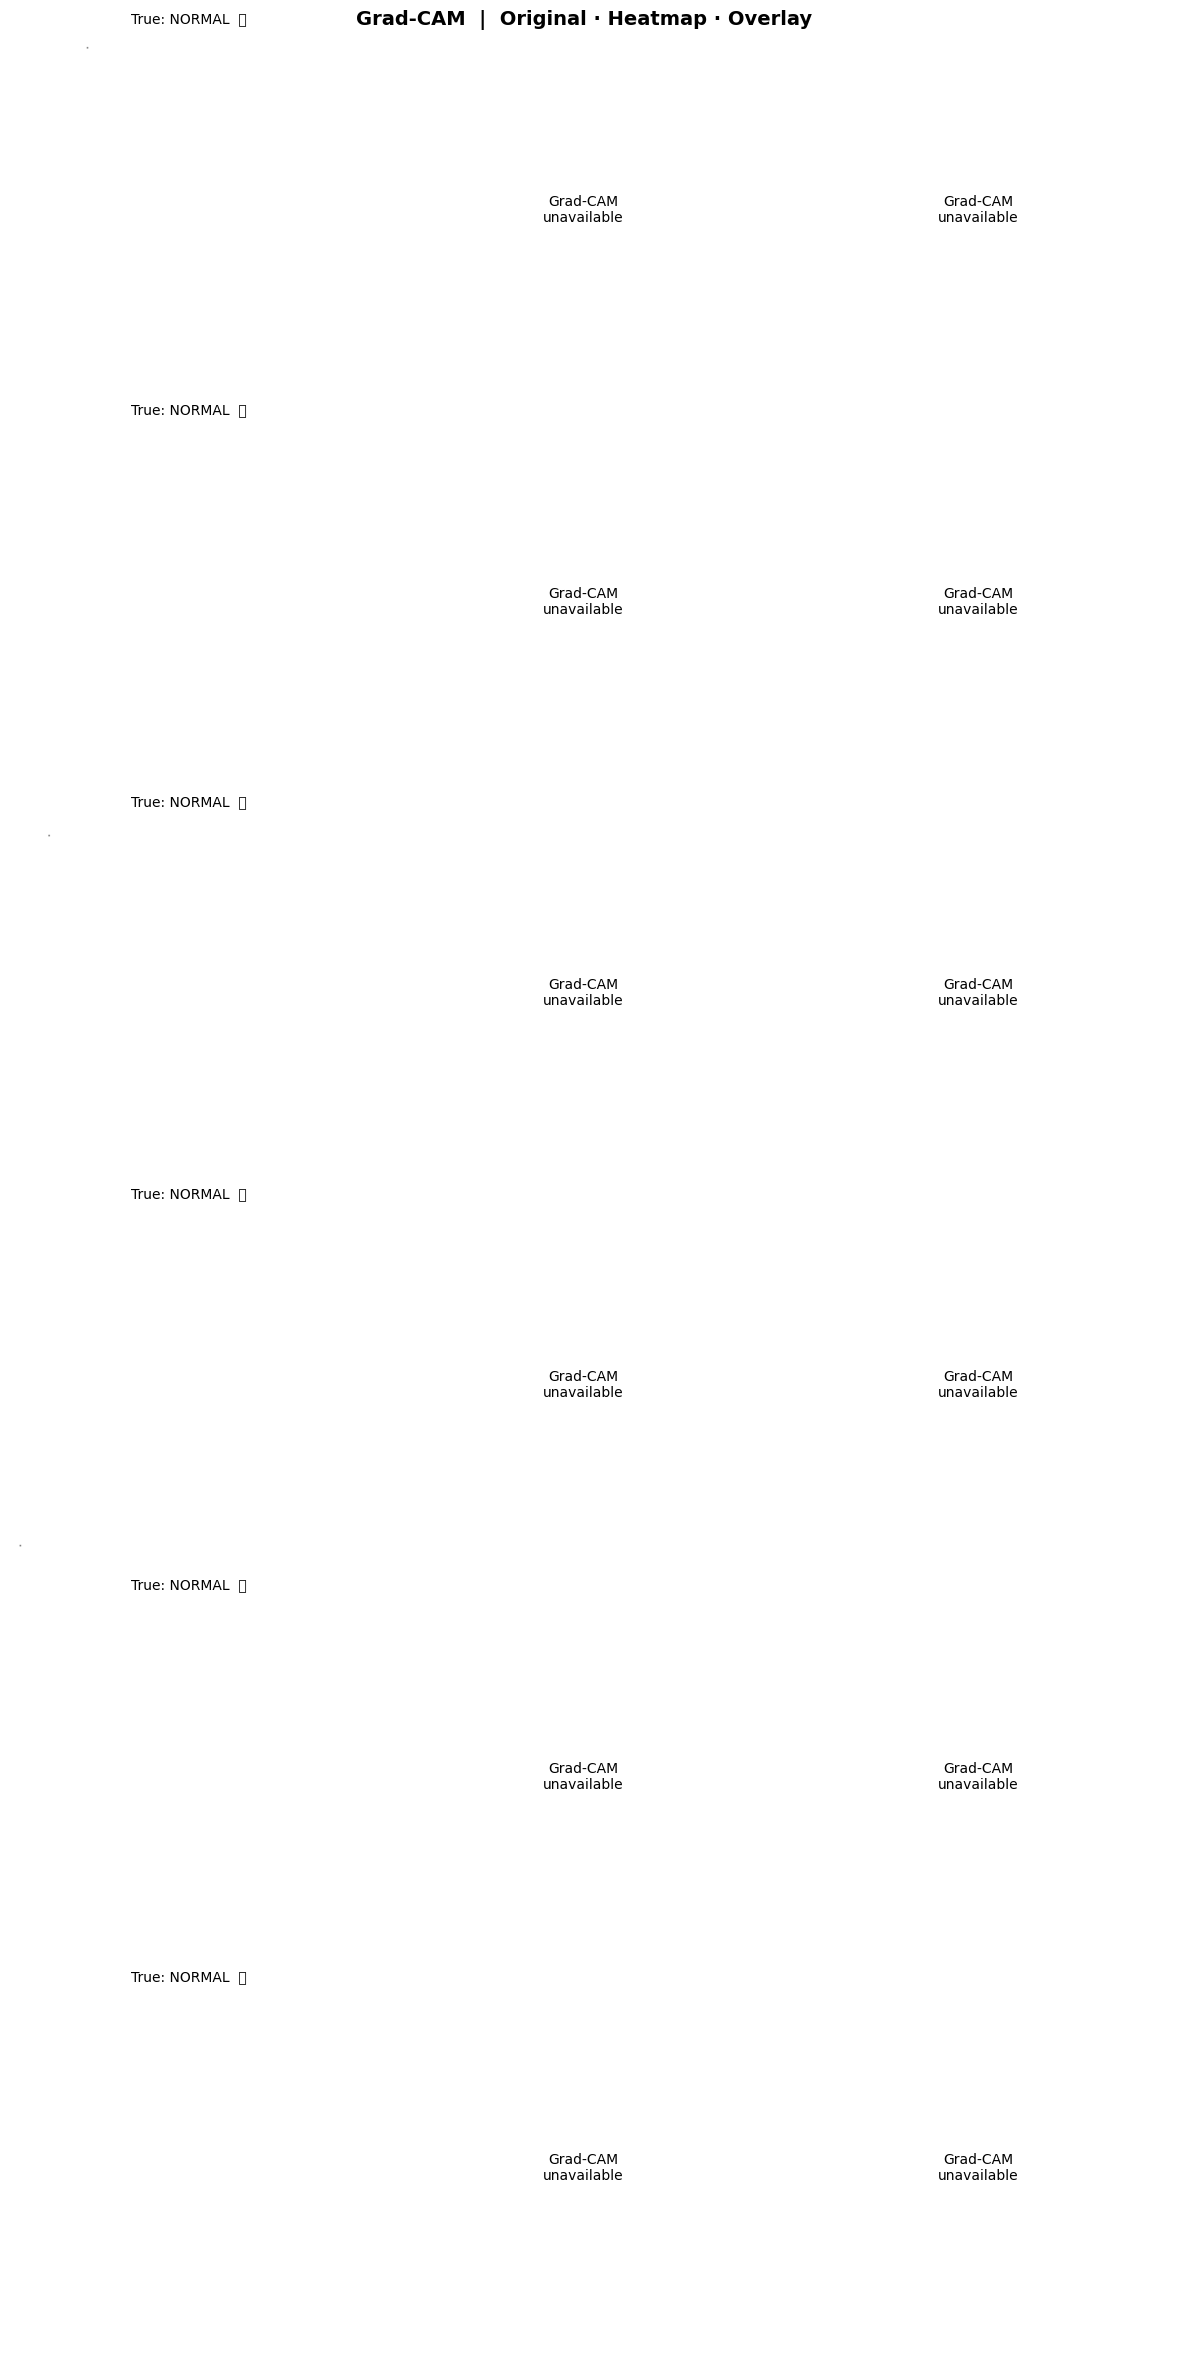

In [20]:
LAST_CONV = 'top_conv'   # Last conv layer name in EfficientNetB3

@tf.function
def _grad_tape(grad_model, img_tensor):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    return conv_out, grads


def compute_gradcam(model, img_array):
    """
    img_array: numpy (1, H, W, 3) already preprocessed
    Returns heatmap (H, W) or None on failure.
    """
    try:
        last_conv = model.get_layer('efficientnetb3').get_layer(LAST_CONV)
        grad_model = Model(
            inputs  = model.inputs,
            outputs = [last_conv.output, model.output]
        )
    except Exception:
        return None

    conv_out, grads = _grad_tape(grad_model, tf.cast(img_array, tf.float32))
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    heatmap  = (conv_out[0].numpy() @ pooled).clip(0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap


def show_gradcam(n: int = 6):
    """Show n test images with Grad-CAM overlays."""
    test_gen.reset()
    imgs_batch, lbl_batch = next(test_gen)
    n = min(n, len(imgs_batch))

    fig, axes = plt.subplots(n, 3, figsize=(12, n*4))
    fig.suptitle('Grad-CAM  |  Original · Heatmap · Overlay', fontsize=14, fontweight='bold')

    for i in range(n):
        img_pp  = imgs_batch[i:i+1]      # preprocessed
        prob    = float(model.predict(img_pp, verbose=0)[0, 0])
        pred    = int(prob >= best_thresh)
        lbl     = int(lbl_batch[i])
        tick    = '✅' if pred == lbl else '❌'

        # Display-ready: undo preprocess_input roughly (just for viz)
        img_vis = (imgs_batch[i] / 2 + 0.5).clip(0, 1)

        axes[i,0].imshow(img_vis, cmap='gray')
        axes[i,0].set_title(f'True: {CLASSES[lbl]}  {tick}', fontsize=10)
        axes[i,0].axis('off')

        hm = compute_gradcam(model, img_pp)
        if hm is not None:
            hm_r = cv2.resize(hm, (IMG_SIZE[1], IMG_SIZE[0]))
            axes[i,1].imshow(hm_r, cmap='jet')
            axes[i,1].set_title(f'Pred: {CLASSES[pred]} ({prob:.2f})', fontsize=10)
            axes[i,1].axis('off')

            img_u8  = (img_vis * 255).astype(np.uint8)
            hm_u8   = cv2.applyColorMap((hm_r*255).astype(np.uint8), cv2.COLORMAP_JET)
            overlay = cv2.addWeighted(img_u8, 0.55, hm_u8, 0.45, 0)
            axes[i,2].imshow(overlay); axes[i,2].axis('off')
        else:
            for j in (1,2):
                axes[i,j].text(0.5,0.5,'Grad-CAM\nunavailable',
                               ha='center',va='center',transform=axes[i,j].transAxes)
                axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_examples.png', dpi=150, bbox_inches='tight')
    plt.show()


show_gradcam(n=6)

## 14. 💾 Save Model & Predict Utility

In [21]:
final_path = MODEL_DIR / 'pneumonia_final.keras'
model.save(final_path)
print(f"Model saved → {final_path}")

Model saved → models/pneumonia_final.keras


In [22]:
def predict_image(image_path: str, threshold: float = best_thresh) -> dict:
    """
    Predict a single X-ray image.

    Args:
        image_path : path to image file
        threshold  : decision threshold (default = optimised value from val)

    Returns:
        dict: label, probability, confidence, threshold_used
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    # Resize → BGR float32 → preprocess_input (matches training pipeline)
    img = cv2.resize(img, IMG_SIZE).astype(np.float32)
    img = preprocess_input(img)      # ← must use same function as training
    inp = np.expand_dims(img, 0)

    prob  = float(model.predict(inp, verbose=0)[0, 0])
    label = CLASSES[int(prob >= threshold)]
    conf  = prob if label == 'PNEUMONIA' else 1.0 - prob

    print(f"  Prediction : {label}")
    print(f"  Probability (PNEUMONIA): {prob:.4f}")
    print(f"  Confidence : {conf:.2%}")
    print(f"  Threshold  : {threshold:.3f}")
    return dict(label=label, probability=prob, confidence=conf, threshold=threshold)


# ── Usage example ─────────────────────────────────────────────────────────────
# result = predict_image('path/to/xray.jpg')
print("predict_image() ready ✓")

predict_image() ready ✓


## 15. 📋 Final Summary

In [23]:
print("\n" + "="*55)
print(" 🏆  FINAL RESULTS SUMMARY")
print("="*55)
print(f"  Test Accuracy     : {acc*100:.2f}%")
print(f"  Test AUC-ROC      : {auc:.4f}")
print(f"  Test F1 Score     : {f1:.4f}")
print(f"  Sensitivity       : {sensitivity:.4f}  (PNEUMONIA recall)")
print(f"  Specificity       : {specificity:.4f}  (NORMAL recall)")
print(f"  Decision threshold: {best_thresh:.3f}")
print(f"  Model path        : {final_path}")
print("="*55)

artifacts = [
    'dataset_distribution.png', 'sample_images.png',
    'training_history.png', 'threshold_search.png',
    'evaluation_metrics.png', 'gradcam_examples.png',
    str(final_path),
]
print("\nSaved files:")
for f in artifacts:
    print(f"  {'✅' if Path(f).exists() else '❌'}  {f}")


 🏆  FINAL RESULTS SUMMARY
  Test Accuracy     : 81.41%
  Test AUC-ROC      : 0.9816
  Test F1 Score     : 0.8702
  Sensitivity       : 0.9974  (PNEUMONIA recall)
  Specificity       : 0.5085  (NORMAL recall)
  Decision threshold: 0.240
  Model path        : models/pneumonia_final.keras

Saved files:
  ✅  dataset_distribution.png
  ✅  sample_images.png
  ✅  training_history.png
  ✅  threshold_search.png
  ✅  evaluation_metrics.png
  ✅  gradcam_examples.png
  ✅  models/pneumonia_final.keras
